# 100 · Chess Siamese Training

Primer Notebook modelo aplicando una red siamesa para el entrenamiento de la búsqueda de estilometría de juego de ajedrez.

In [1]:
import os
import json
import math
import random
import logging
import itertools
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from datetime import datetime

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

SEED = 314159
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as gpu_err:
            logging.warning("No se pudo configurar memory_growth en %s: %s", gpu, gpu_err)
else:
    logging.warning("No se encontraron GPUs: se entrenará en CPU.")

print(f"TensorFlow {tf.__version__}")

2026-02-09 07:09:05.225184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-09 07:09:05.332942: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-09 07:09:05.366400: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-09 07:09:05.532277: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.17.0


I0000 00:00:1770620949.746690     450 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770620950.178751     450 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770620950.178816     450 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
def detect_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "labs").exists():
            return candidate
    raise RuntimeError("No pude localizar el directorio 'labs'. Ejecuta este notebook desde la raíz del repo o desde labs/.")

REPO_ROOT = detect_repo_root()
LABS_DIR = REPO_ROOT / "labs"

CONFIG = {
    "event_name": "Rated_Blitz_game",
    "num_blocks": 3,
    "image_size": (192, 192),
    "players_limit": 100,
    "min_samples_per_player": 4,
    "max_games_per_player": 40,
    "validation_fraction": 0.2,
    "triplets_per_epoch": 8192,
    "val_triplets": 2048,
    "batch_size": 24,
    "epochs": 30,
    "margin": 0.4,
    "learning_rate": 1e-4,
    "players_whitelist": None,
    "embedding_cache_dir": LABS_DIR / "dataset" / "embedding",
    "seed": SEED,
}

EVENT_DIR = LABS_DIR / "notebooks" / "output" / "events" / CONFIG["event_name"]
BOARD_DIR = EVENT_DIR / "board_images"
HEAT_DIR = EVENT_DIR / "heatmap_images"
BLOCK_LABELS = [f"block_{i+1:02d}" for i in range(CONFIG["num_blocks"])]

print(f"Repositorio raíz: {REPO_ROOT}")
print(f"Evento seleccionado: {CONFIG['event_name']}")
print(f"Bloques esperados: {BLOCK_LABELS}")

Repositorio raíz: /workspace/code
Evento seleccionado: Rated_Blitz_game
Bloques esperados: ['block_01', 'block_02', 'block_03']


In [3]:
@dataclass(frozen=True)
class GameSample:
    player: str
    game_id: str
    board_paths: Tuple[str, ...]
    heat_paths: Tuple[str, ...]
    event: str


def ensure_dataset_ready():
    missing = [str(path) for path in (EVENT_DIR, BOARD_DIR, HEAT_DIR) if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "No se encontraron las imágenes generadas para el evento "
            f"{CONFIG['event_name']}.\n"
            "Ejecuta antes el pipeline desde labs/src/pipeline_stylometry_blocks.py "
            "para poblar board_images y heatmap_images."
        )


def discover_game_samples(
    board_dir: Path,
    heat_dir: Path,
    block_labels: List[str],
    players_limit: Optional[int] = None,
    whitelist: Optional[List[str]] = None,
    min_samples: int = 4,
    max_games_per_player: Optional[int] = None,
) -> Tuple[Dict[str, List[GameSample]], pd.DataFrame]:
    ensure_dataset_ready()
    if not block_labels:
        raise ValueError("Se requiere al menos un bloque configurado.")
    whitelist_set = None
    if whitelist:
        whitelist_set = {name.replace(" ", "_") for name in whitelist}
    samples_by_player: Dict[str, List[GameSample]] = {}
    player_dirs = sorted([d for d in board_dir.iterdir() if d.is_dir()])
    if not player_dirs:
        raise RuntimeError(f"No se encontraron subdirectorios en {board_dir}.")
    first_block = block_labels[0]
    for player_dir in player_dirs:
        player_name = player_dir.name
        if whitelist_set and player_name not in whitelist_set:
            continue
        heat_player_dir = heat_dir / player_name
        if not heat_player_dir.exists():
            logging.warning("Saltando %s: falta carpeta de heatmaps.", player_name)
            continue
        game_ids = sorted({path.stem.split('_')[1] for path in player_dir.glob(f"game_*_{first_block}.png")})
        if not game_ids:
            continue
        player_samples: List[GameSample] = []
        for game_id in game_ids:
            board_paths = []
            heat_paths = []
            valid = True
            for block_label in block_labels:
                board_path = player_dir / f"game_{game_id}_{block_label}.png"
                heat_path = heat_player_dir / f"game_{game_id}_{block_label}.png"
                if not board_path.exists() or not heat_path.exists():
                    valid = False
                    break
                board_paths.append(str(board_path))
                heat_paths.append(str(heat_path))
            if not valid:
                continue
            player_samples.append(
                GameSample(
                    player=player_name,
                    game_id=game_id,
                    board_paths=tuple(board_paths),
                    heat_paths=tuple(heat_paths),
                    event=CONFIG["event_name"],
                )
            )
            if max_games_per_player and len(player_samples) >= max_games_per_player:
                break
        if len(player_samples) >= min_samples:
            samples_by_player[player_name] = player_samples
    if not samples_by_player:
        raise RuntimeError("No hay jugadores con suficientes partidas. Verifica que el pipeline haya generado datos.")
    sorted_players = sorted(samples_by_player.items(), key=lambda item: len(item[1]), reverse=True)
    if players_limit:
        sorted_players = sorted_players[:players_limit]
    filtered = {player: samples_by_player[player] for player, _ in sorted_players}
    stats_df = pd.DataFrame(
        [{"player": player, "games": len(samples)} for player, samples in filtered.items()]
    ).sort_values("games", ascending=False).reset_index(drop=True)
    return filtered, stats_df


samples_by_player, player_stats = discover_game_samples(
    BOARD_DIR,
    HEAT_DIR,
    BLOCK_LABELS,
    players_limit=CONFIG["players_limit"],
    whitelist=CONFIG["players_whitelist"],
    min_samples=CONFIG["min_samples_per_player"],
    max_games_per_player=CONFIG["max_games_per_player"],
)


display(player_stats.head(20))

total_players = len(samples_by_player)
total_games = sum(len(samples) for samples in samples_by_player.values())
print(f"Jugadores válidos: {total_players}")
print(f"Partidas disponibles: {total_games}")

,player,games
0,Aydin86,40
1,ivan_tsventukh,40
2,DeathIsReal,40
3,Siric1389,40
4,AleksoSanchees,39
5,Lagavulin1987,39
6,LeeNewport31,39
7,NeverSettleCastle,39
8,jumem2456,39
9,rabitneto,39


Jugadores válidos: 100
Partidas disponibles: 3548


In [4]:
def split_samples_by_player(
    samples_by_player: Dict[str, List[GameSample]],
    val_fraction: float,
    seed: int,
) -> Tuple[Dict[str, List[GameSample]], Dict[str, List[GameSample]], List[GameSample], List[GameSample]]:
    rng = random.Random(seed)
    train_dict: Dict[str, List[GameSample]] = {}
    val_dict: Dict[str, List[GameSample]] = {}
    for player, samples in samples_by_player.items():
        copies = samples.copy()
        rng.shuffle(copies)
        if len(copies) < 2:
            logging.warning("Descartando %s: solo %d partidas disponibles.", player, len(copies))
            continue
        val_count = max(1, int(len(copies) * val_fraction))
        while val_count > 0 and len(copies) - val_count < 2:
            val_count -= 1
        val_samples = copies[:val_count] if val_count > 0 else []
        train_samples = copies[val_count:]
        if len(train_samples) < 2:
            logging.warning("Descartando %s: no quedan ≥2 partidas para entrenamiento tras el split.", player)
            continue
        train_dict[player] = train_samples
        val_dict[player] = val_samples
    train_samples_flat = [sample for samples in train_dict.values() for sample in samples]
    val_samples_flat = [sample for samples in val_dict.values() for sample in samples]
    if not train_samples_flat:
        raise RuntimeError("El split produjo 0 muestras de entrenamiento.")
    return train_dict, val_dict, train_samples_flat, val_samples_flat


train_by_player, val_by_player, TRAIN_SAMPLES, VAL_SAMPLES = split_samples_by_player(
    samples_by_player,
    CONFIG["validation_fraction"],
    CONFIG["seed"],
)

print(f"Muestras de entrenamiento: {len(TRAIN_SAMPLES)}")
print(f"Muestras de validación: {len(VAL_SAMPLES)}")

pd.DataFrame(
    {
        "player": list(train_by_player.keys()),
        "train_games": [len(v) for v in train_by_player.values()],
        "val_games": [len(val_by_player.get(player, [])) for player in train_by_player.keys()],
    }
).sort_values("train_games", ascending=False).reset_index(drop=True).head(10)

Muestras de entrenamiento: 2886
Muestras de validación: 662


,player,train_games,val_games
0,Aydin86,32,8
1,Siric1389,32,8
2,ivan_tsventukh,32,8
3,AleksoSanchees,32,7
4,Lagavulin1987,32,7
5,LeeNewport31,32,7
6,NeverSettleCastle,32,7
7,jumem2456,32,7
8,rabitneto,32,7
9,DeathIsReal,32,8


In [5]:
IMG_HEIGHT, IMG_WIDTH = CONFIG["image_size"]
NUM_BLOCKS = CONFIG["num_blocks"]


class TripletFactory:
    def __init__(self, samples_by_player: Dict[str, List[GameSample]]):
        self.samples_by_player = {
            player: tuple(samples) for player, samples in samples_by_player.items() if len(samples) >= 2
        }
        self.players = sorted(self.samples_by_player.keys())
        if len(self.players) < 2:
            raise ValueError("Se requieren ≥2 jugadores con al menos 2 partidas cada uno para formar tripletes.")

    def build(self, num_triplets: int, seed: int) -> List[Tuple[GameSample, GameSample, GameSample]]:
        rng = random.Random(seed)
        triplets: List[Tuple[GameSample, GameSample, GameSample]] = []
        max_attempts = max(num_triplets * 20, 1000)
        attempts = 0
        while len(triplets) < num_triplets and attempts < max_attempts:
            attempts += 1
            anchor_player = rng.choice(self.players)
            positives = self.samples_by_player[anchor_player]
            if len(positives) < 2:
                continue
            anchor_sample, positive_sample = rng.sample(positives, 2)
            negative_candidates = [p for p in self.players if p != anchor_player]
            if not negative_candidates:
                continue
            negative_player = rng.choice(negative_candidates)
            negative_sample = rng.choice(self.samples_by_player[negative_player])
            triplets.append((anchor_sample, positive_sample, negative_sample))
        if len(triplets) < num_triplets:
            logging.warning("Solo se crearon %d/%d tripletes (dataset limitado).", len(triplets), num_triplets)
        return triplets


def serialize_triplets(triplets: List[Tuple[GameSample, GameSample, GameSample]]) -> Dict[str, np.ndarray]:
    arrays = {
        "anchor_board": [],
        "anchor_heat": [],
        "positive_board": [],
        "positive_heat": [],
        "negative_board": [],
        "negative_heat": [],
    }
    for anchor, positive, negative in triplets:
        arrays["anchor_board"].append(anchor.board_paths)
        arrays["anchor_heat"].append(anchor.heat_paths)
        arrays["positive_board"].append(positive.board_paths)
        arrays["positive_heat"].append(positive.heat_paths)
        arrays["negative_board"].append(negative.board_paths)
        arrays["negative_heat"].append(negative.heat_paths)
    return {k: np.array(v) for k, v in arrays.items()}


def _decode_board(path: tf.Tensor) -> tf.Tensor:
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image


def _decode_heat(path: tf.Tensor) -> tf.Tensor:
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image


def load_sample(board_paths: tf.Tensor, heat_paths: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
    board = tf.map_fn(
        _decode_board,
        board_paths,
        fn_output_signature=tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32),
        parallel_iterations=NUM_BLOCKS,
    )
    heat = tf.map_fn(
        _decode_heat,
        heat_paths,
        fn_output_signature=tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, 1), dtype=tf.float32),
        parallel_iterations=NUM_BLOCKS,
    )
    return board, heat


_DEF_BUFFER_SIZE = 1000

def build_tf_dataset(
    triplet_dict: Dict[str, np.ndarray],
    batch_size: int,
    shuffle: bool,
    description: str,
) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices(triplet_dict)
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(triplet_dict["anchor_board"]),
            seed=CONFIG["seed"],
            reshuffle_each_iteration=True,
        )

    def mapper(sample):
        anchor_board, anchor_heat = load_sample(sample["anchor_board"], sample["anchor_heat"])
        positive_board, positive_heat = load_sample(sample["positive_board"], sample["positive_heat"])
        negative_board, negative_heat = load_sample(sample["negative_board"], sample["negative_heat"])
        features = (
            anchor_board,
            anchor_heat,
            positive_board,
            positive_heat,
            negative_board,
            negative_heat,
        )
        return features, tf.zeros((1,), dtype=tf.float32)

    ds = ds.map(mapper, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    num_elements = len(triplet_dict["anchor_board"])
    num_batches = max(1, math.ceil(num_elements / batch_size))
    print(f"{description}: {num_elements} tripletes (~{num_batches} batches)")
    return ds


triplet_factory = TripletFactory(train_by_player)

train_triplets = triplet_factory.build(CONFIG["triplets_per_epoch"], CONFIG["seed"])
val_triplets = triplet_factory.build(CONFIG["val_triplets"], CONFIG["seed"] + 41)

train_dataset = build_tf_dataset(serialize_triplets(train_triplets), CONFIG["batch_size"], shuffle=True, description="Train")
val_dataset = build_tf_dataset(serialize_triplets(val_triplets), CONFIG["batch_size"], shuffle=False, description="Val")

I0000 00:00:1770624837.765181     450 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770624837.766456     450 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770624837.766518     450 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770624838.172948     450 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770624838.173104     450 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-09

Train: 8192 tripletes (~342 batches)
Val: 2048 tripletes (~86 batches)


In [8]:
def build_embedding_model(num_blocks: int, img_shape: Tuple[int, int]) -> Model:
    board_input = layers.Input(shape=(num_blocks, img_shape[0], img_shape[1], 3), name="board_sequence")
    heat_input = layers.Input(shape=(num_blocks, img_shape[0], img_shape[1], 1), name="heat_sequence")
# efficientNetB0
    base_cnn = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(img_shape[0], img_shape[1], 3),
    )
    base_cnn.trainable = False

    board_encoder = tf.keras.Sequential(
        [
            base_cnn,
            layers.GlobalAveragePooling2D(),
            layers.Dense(512, activation="gelu"),
            layers.Dropout(0.2),
        ],
        name="board_encoder",
    )

    heat_encoder = tf.keras.Sequential(
        [
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(2),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation="gelu"),
        ],
        name="heat_encoder",
    )

    board_features = layers.TimeDistributed(board_encoder, name="board_td")(board_input)
    heat_features = layers.TimeDistributed(heat_encoder, name="heat_td")(heat_input)
    fused = layers.Concatenate(name="block_fusion")([board_features, heat_features])
    fused = layers.LayerNormalization()(fused)
    fused = layers.TimeDistributed(layers.Dense(256, activation="gelu"), name="block_dense")(fused)

    masked_sequence = layers.Masking(mask_value=0.0, name="temporal_mask")(fused)

    temporal = layers.Bidirectional(
        layers.GRU(256, return_sequences=True),
        name="temporal_encoder",
    )(masked_sequence)
    pooled = layers.GlobalAveragePooling1D(name="temporal_pool")(temporal)
    dense = layers.Dense(512, activation="gelu")(pooled)
    dense = layers.Dropout(0.3)(dense)
    dense = layers.Dense(256, activation="gelu")(dense)
    normalized = layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1), name="l2_norm")(dense)

    return Model(inputs=[board_input, heat_input], outputs=normalized, name="stylometry_embedding")


class DistanceLayer(layers.Layer):
    def call(self, anchor, positive, negative):
        ap_distance = tf.reduce_sum(tf.square(anchor - positive), axis=1)
        an_distance = tf.reduce_sum(tf.square(anchor - negative), axis=1)
        return ap_distance, an_distance


class SiameseModel(Model):
    def __init__(self, siamese_network: Model, margin: float = 0.4):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def _compute_loss(self, data):
        siamese_inputs, _ = data
        ap_distance, an_distance = self.siamese_network(siamese_inputs, training=True)
        loss = tf.maximum(ap_distance - an_distance + self.margin, 0.0)
        return tf.reduce_mean(loss)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.siamese_network.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        siamese_inputs, _ = data
        ap_distance, an_distance = self.siamese_network(siamese_inputs, training=False)
        loss = tf.maximum(ap_distance - an_distance + self.margin, 0.0)
        loss = tf.reduce_mean(loss)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker]

In [14]:
embedding_model = build_embedding_model(CONFIG["num_blocks"], CONFIG["image_size"])


def build_branch(prefix: str):
    board_input = layers.Input(shape=(CONFIG["num_blocks"], IMG_HEIGHT, IMG_WIDTH, 3), name=f"{prefix}_board")
    heat_input = layers.Input(shape=(CONFIG["num_blocks"], IMG_HEIGHT, IMG_WIDTH, 1), name=f"{prefix}_heat")
    embedding = embedding_model([board_input, heat_input])
    return board_input, heat_input, embedding


anchor_board_in, anchor_heat_in, anchor_embedding = build_branch("anchor")
positive_board_in, positive_heat_in, positive_embedding = build_branch("positive")
negative_board_in, negative_heat_in, negative_embedding = build_branch("negative")

distance_layer = DistanceLayer(name="distance")
ap_distance, an_distance = distance_layer(anchor_embedding, positive_embedding, negative_embedding)

siamese_network = Model(
    inputs=[
        anchor_board_in,
        anchor_heat_in,
        positive_board_in,
        positive_heat_in,
        negative_board_in,
        negative_heat_in,
    ],
    outputs=(ap_distance, an_distance),
    name="siamese_network",
)

siamese_network.summary(line_length=140)

siamese_model = SiameseModel(siamese_network, margin=CONFIG["margin"])
optimizer = tf.keras.optimizers.Adam(CONFIG["learning_rate"])
siamese_model.compile(optimizer=optimizer)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=20,
        min_lr=1e-6,
        verbose=1,
    ),
]


history = siamese_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=CONFIG["epochs"],
    callbacks=callbacks,
    verbose=1,
)

Model: "siamese_network"
____________________________________________________________________________________________________________________________________________
 Layer (type)                             Output Shape                              Param #       Connected to                              
 anchor_board (InputLayer)                [(None, 3, 192, 192, 3)]                  0             []                                        
                                                                                                                                            
 anchor_heat (InputLayer)                 [(None, 3, 192, 192, 1)]                  0             []                                        
                                                                                                                                            
 positive_board (InputLayer)              [(None, 3, 192, 192, 3)]                  0             []                             

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/342 [..............................] - ETA: 5:19:06 - loss: 0.3835

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


342/342 [==============================] - 176s 351ms/step - loss: 0.4004 - val_loss: 0.4000 - lr: 1.0000e-04
Epoch 2/30
342/342 [==============================] - 116s 338ms/step - loss: 0.4004 - val_loss: 0.4000 - lr: 1.0000e-04
Epoch 3/30
342/342 [==============================] - 103s 301ms/step - loss: 0.3988 - val_loss: 0.4000 - lr: 1.0000e-04
Epoch 4/30
342/342 [==============================] - 105s 297ms/step - loss: 0.3995 - val_loss: 0.4000 - lr: 1.0000e-04
Epoch 5/30
342/342 [==============================] - 106s 309ms/step - loss: 0.4002 - val_loss: 0.4000 - lr: 1.0000e-04
Epoch 6/30
342/342 [==============================] - 120s 351ms/step - loss: 0.4008 - val_loss: 0.4000 - lr: 1.0000e-04
Epoch 7/30
342/342 [==============================] - 114s 332ms/step - loss: 0.4003 - val_loss: 0.4000 - lr: 1.0000e-04
Epoch 8/30
342/342 [==============================] - 114s 332ms/step - loss: 0.4010 - val_loss: 0.4000 - lr: 1.0000e-04
Epoch 9/30
342/342 [=======================

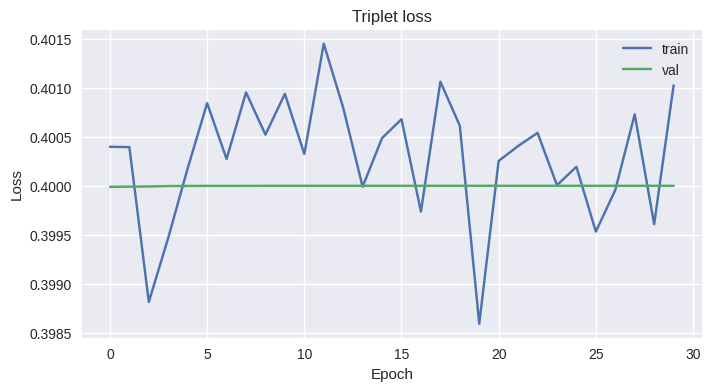

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(history.history.get("loss", []), label="train")
plt.plot(history.history.get("val_loss", []), label="val")
plt.title("Triplet loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
def build_embedding_dataset(samples: List[GameSample], batch_size: int):
    if not samples:
        raise RuntimeError("No hay muestras para evaluar.")
    board_paths = np.array([sample.board_paths for sample in samples])
    heat_paths = np.array([sample.heat_paths for sample in samples])
    metadata = [{"player": sample.player, "game_id": sample.game_id} for sample in samples]
    ds = tf.data.Dataset.from_tensor_slices({"board": board_paths, "heat": heat_paths})
    ds = ds.map(lambda sample: load_sample(sample["board"], sample["heat"]), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, metadata


val_embed_ds, val_metadata = build_embedding_dataset(VAL_SAMPLES, CONFIG["batch_size"])
val_embeddings = embedding_model.predict(val_embed_ds, verbose=1)

positive_distances = []
negative_distances = []
for i in range(len(val_embeddings)):
    for j in range(i + 1, len(val_embeddings)):
        dist = float(np.linalg.norm(val_embeddings[i] - val_embeddings[j]))
        if val_metadata[i]["player"] == val_metadata[j]["player"]:
            positive_distances.append(dist)
        else:
            negative_distances.append(dist)


def summarize_distances(name: str, values: List[float]):
    if not values:
        return {"set": name, "count": 0, "mean": None, "median": None}
    return {
        "set": name,
        "count": len(values),
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


distance_summary = pd.DataFrame(
    [
        summarize_distances("intra-player", positive_distances),
        summarize_distances("inter-player", negative_distances),
    ]
)

display(distance_summary)

plt.figure(figsize=(8, 4))
plt.hist(positive_distances, bins=30, alpha=0.7, label="intra-player")
plt.hist(negative_distances, bins=30, alpha=0.7, label="inter-player")
plt.xlabel("L2 distance")
plt.ylabel("Frequency")
plt.title("Distribución de distancias en validación")
plt.legend()
plt.show()

ValueError: in user code:

    File "/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py", line 2436, in predict_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py", line 2421, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py", line 2409, in run_step  **
        outputs = model.predict_step(data)
    File "/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py", line 2377, in predict_step
        return self(x, training=False)
    File "/usr/local/lib/python3.12/dist-packages/tf_keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/input_spec.py", line 219, in assert_input_compatibility
        raise ValueErr

In [ ]:
def export_embedding_cache(samples: List[GameSample], model: Model, output_dir: Path):
    output_dir = Path(output_dir) / CONFIG["event_name"]
    output_dir.mkdir(parents=True, exist_ok=True)
    ds, metadata = build_embedding_dataset(samples, CONFIG["batch_size"])
    embeddings = model.predict(ds, verbose=1)

    centroids: Dict[str, List[np.ndarray]] = {}
    for emb, meta in zip(embeddings, metadata):
        player_dir = output_dir / meta["player"]
        player_dir.mkdir(parents=True, exist_ok=True)
        sample_path = player_dir / f"{meta['game_id']}.npy"
        np.save(sample_path, emb.astype(np.float32))
        centroids.setdefault(meta["player"], []).append(emb)

    centroid_payload = {}
    for player, vectors in centroids.items():
        stacked = np.vstack(vectors)
        centroid = np.mean(stacked, axis=0)
        centroid_path = output_dir / player / "centroid.npy"
        np.save(centroid_path, centroid.astype(np.float32))
        centroid_payload[player] = {
            "samples": len(vectors),
            "centroid_path": str(centroid_path),
        }

    manifest = {
        "event": CONFIG["event_name"],
        "players": len(centroid_payload),
        "updated_at": datetime.utcnow().isoformat() + "Z",
        "vectors": centroid_payload,
    }
    manifest_path = output_dir / "manifest.json"
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)
    print(f"Embeddings exportados a {output_dir}")
    return manifest_path


embedding_manifest = export_embedding_cache(TRAIN_SAMPLES, embedding_model, CONFIG["embedding_cache_dir"])
print(f"Manifest: {embedding_manifest}")